# Test
Si addestri il regressore desiderato utilizzando gli iperparametri trovati nell'esercizio precedente. Il codice contenuto nella cella seguente userà tale regressore per predire la potenza prodotta nell'ora successiva a partire dai pattern del dataset di test. I valori predetti verranno memorizzati su un file di testo che dovrà essere caricato sul sito della competizione per misurarne l'RMSE.

In [7]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from pre_processing import extract_datetime_feature, augment_temperature, pre_process
from matplotlib import pyplot as plt

In [8]:
train_path = './DBs/SolarPark/train.txt'
test_path = './DBs/SolarPark/test.txt'
result_path = 'Es5Predictions.txt'

train_dataframe,train_pure_dataframe = pre_process(train_path,debug=False)
feature_x = np.append(train_dataframe.values[:,2:6],train_dataframe.values[:,7:12],axis=1)
feature_pure_x = np.append(train_pure_dataframe.values[:,2:6],train_pure_dataframe.values[:,7:12],axis=1)
feature_y = train_dataframe.values[:,6]
feature_pure_y = train_pure_dataframe.values[:,6]

# Cast di tutti i valori a float32
feature_x = feature_x.astype(np.float32)
feature_y = feature_y.astype(np.float32)

# Cast di tutti i valori a float32
feature_pure_x = feature_pure_x.astype(np.float32)
feature__pure_y = feature_pure_y.astype(np.float32)

In [9]:
predict_ahead = True

if predict_ahead:
    # Sfasa i dati: le prediction sono quelle dell'ora successiva
    data_x = feature_x[0:-1,:]
    data_y = feature_y[1:]
    data_pure_x = feature_pure_x[0:-1,:]
    data_pure_y = feature_pure_y[1:]
else:
    data_x = feature_x
    data_y = feature_y
    data_pure_x = feature_pure_x
    data_pure_y = feature_pure_y

In [10]:
valid_portion = 0.3
split_random = True


if split_random:
    # Split casuale di train e validation set
    train_x, validation_x, train_y, validation_y = train_test_split(data_x, data_y, test_size=valid_portion, random_state=1)
else:
    # Split temporale
    train_x, validation_x, train_y, validation_y = train_test_split(data_x, data_y, test_size=valid_portion, shuffle=False)

In [11]:
forest_reg = RandomForestRegressor(n_estimators=10)
forest_reg.fit(train_x, train_y)

# Ottenimento delle predizioni
train_y_predicted = forest_reg.predict(train_x)

# Calcolo del RMSE
rmse = np.sqrt(mean_squared_error(train_y, train_y_predicted))
print('Train RMSE: ', rmse)

# Ottenimento delle predizioni (validation) e calcolo RMSE
validation_y_predicted = forest_reg.predict(validation_x)
rmse = np.sqrt(mean_squared_error(validation_y, validation_y_predicted))
print('Validation RMSE: ', rmse)

print('R2 score:', forest_reg.score(validation_x, validation_y))

Train RMSE:  42.15338356311004
Validation RMSE:  101.06547491674176
R2 score: 0.824807436937866


In [12]:
# /////// LOAD AND GET TEST_Y FEATURES ///////
test_dataframe = pd.read_csv(test_path)
test_dataframe = extract_datetime_feature(df=test_dataframe, date_column='Date', remove=False, is_timestamp=True)
test_dataframe = augment_temperature(df=test_dataframe, replace=False, columns=["Ta (C)", "Tm (C)"])
test_y = np.append(test_dataframe.values[:,2:6],test_dataframe.values[:,7:12],axis=1)
# /////// END  ///////


# Ottenimento delle predizioni (validation) e calcolo RMSE
prediction = forest_reg.predict(test_y)
# rmse = np.sqrt(mean_squared_error(test_y, prediction))
# print('Test RMSE: ', rmse)

print('R2 TEST score:', forest_reg.score(test_y, prediction))

# Calcola l'errore come scostamento delle predizioni dal valore reale
errors = np.abs(validation_y - validation_y_predicted)

R2 TEST score: 1.0


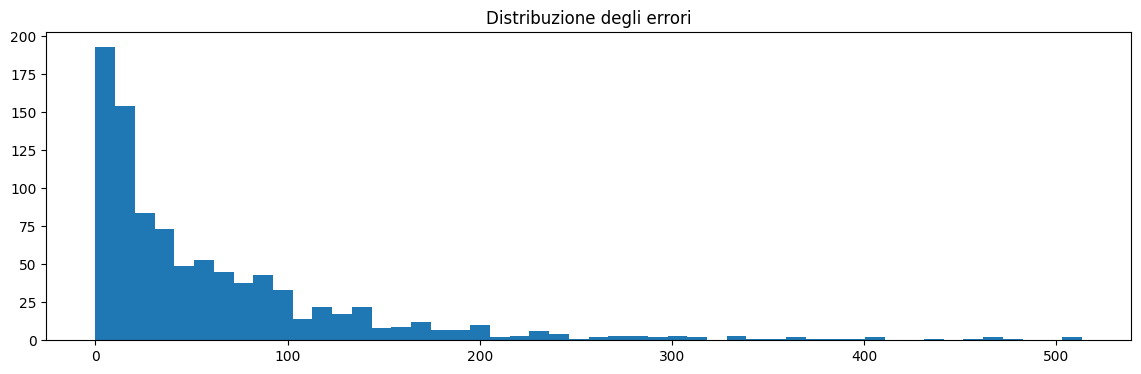

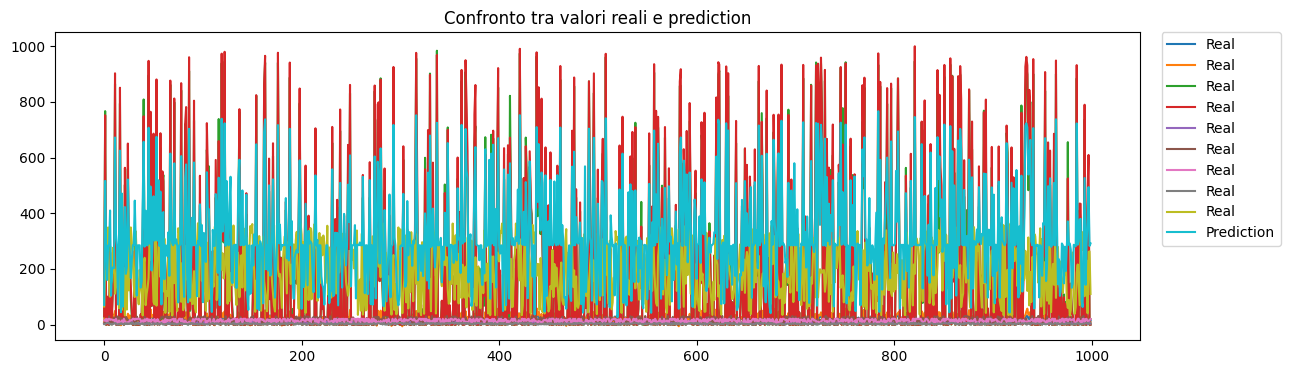

In [13]:
plt.figure(figsize=(14, 4))
plt.title("Distribuzione degli errori")
plt.hist(x = errors, bins=50)
plt.show()

# Visualizza l'andamento reale e quello predetto
plt.figure(figsize=(14, 4))
plt.title("Confronto tra valori reali e prediction")
plt.plot(test_y[0:1000], label='Real')
plt.plot(prediction[0:1000], label='Prediction')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.show()